Loading the cleaned data To create visualizations and give insights on the best time to book flight tickets And give suitable recommendations. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/flight_pricing_cleaned.csv")
print("Shape:", df.shape)
df.head()

Shape: (98039, 18)


,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price,Duration_Minutes
0,FL133547,Indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,0.0,910.5,Economy,43.0,Monsoon,Saturday,Boeing 737,Mobile App,5.0,5181.56,100.2
1,FL133458,AirAsia India,Pune,Mumbai,2025-06-05,12:10,12:55,0.0,150.0,Economy,45.0,Monsoon,Thursday,ATR 72,Website,3.0,2000.00,45.0
2,FL173851,Qatar Airways,Sydney,Pune,2025-02-11,5:05 PM,7:53 AM,1.0,10168.1,Economy,3.0,NaN,Tuesday,Boeing 777,Mobile App,3.0,174762.69,888.0
3,FL101953,AirAsia India,Bangalore,Mumbai,2025-04-19,07:05,10:16 AM,1.0,868.3,Economy,33.0,Summer,Saturday,Airbus A320,Mobile App,1.0,2846.09,191.0
4,FL162887,British Airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,0.0,10478.0,Economy,6.0,Monsoon,Sunday,Airbus A320,Website,2.0,145331.64,835.8


Price distribution is important as it helps us understand how much flights usually cost and whether they are very cheap or very expensive tickets, and it is a very important category for visualizing. 

Visualization 1 :

Histogram is used to show how ticket flight prices are spread. We also add a KDE line, which makes the overall shape easier to understand for us. 

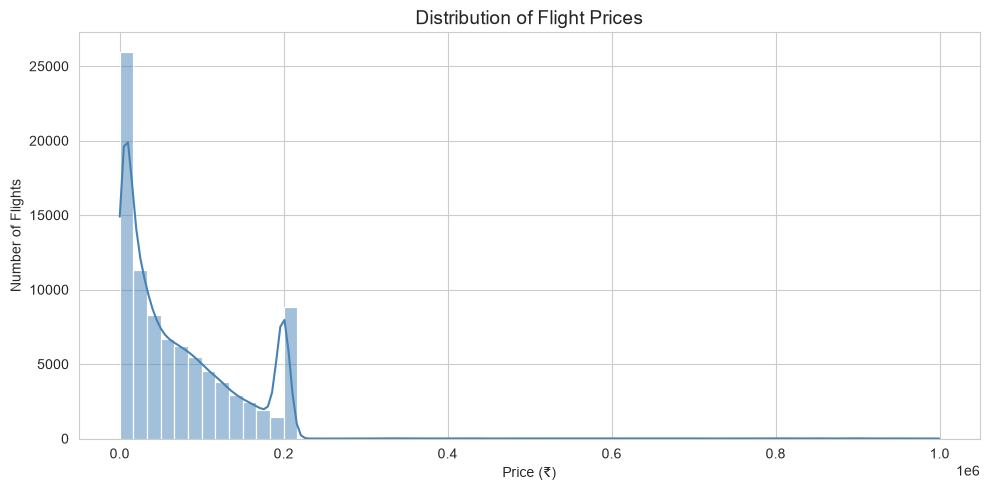

Skewness: 3.1
Median price: ₹49,159
Mean price:   ₹73,026


In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=60, kde=True, color='steelblue')
plt.title('Distribution of Flight Prices', fontsize=14)
plt.xlabel('Price (₹)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

print("Skewness:", df['Price'].skew().round(2))
print("Median price: ₹{:,.0f}".format(df['Price'].median()))
print("Mean price:   ₹{:,.0f}".format(df['Price'].mean()))

**Insight:**
- The distribution is right-skewed (long tail toward high prices) — a positive skewness
  value confirms this, and the fact that mean > median is the classic signature of a
  right-skewed distribution.
- This means: most flights are moderately priced, but a smaller number of expensive
  flights (long-haul, business/first class) pull the average up. **The median is a more
  representative "typical price" than the mean** for this dataset — worth stating
  explicitly, since it changes how you'd summarize "average" price to someone.

Visualization 2:

Another fact is that many airlines have higher prices compared to others, so this is also another important category in the analysis. 

C:\Users\DELL\AppData\Local\Temp\ipykernel_23116\1418878600.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Airline', y='Price', order=order, palette='viridis')


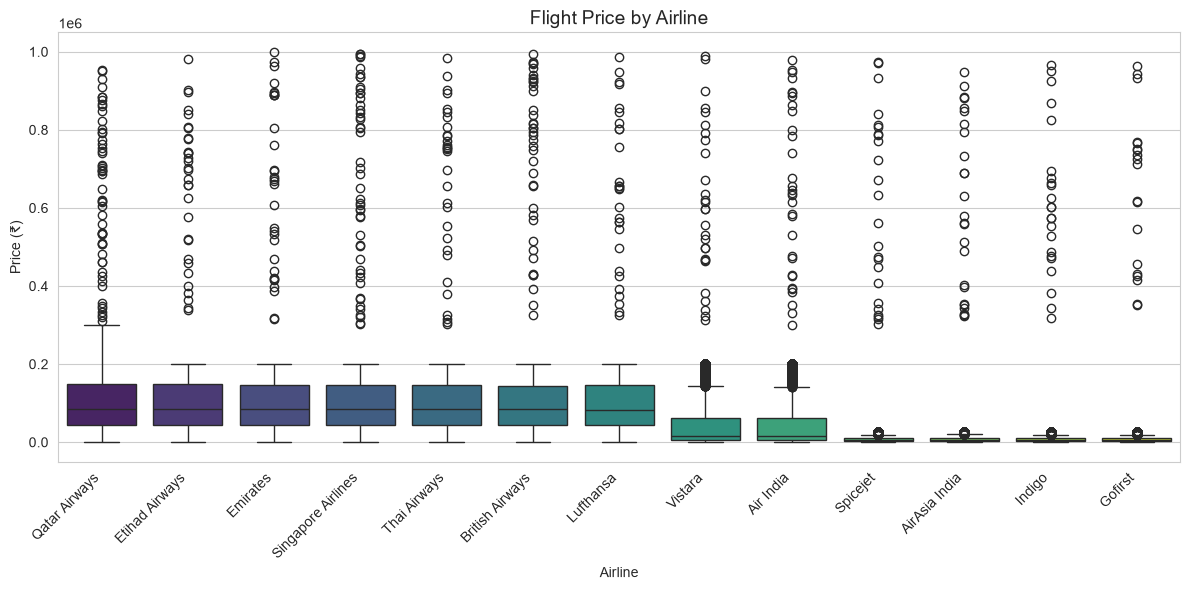

Airline
Qatar Airways         86060.265
Etihad Airways        85175.985
Emirates              85115.960
Singapore Airlines    84814.605
Thai Airways          84802.265
British Airways       84100.920
Lufthansa             83152.245
Vistara               16949.640
Air India             16470.875
Spicejet               6224.660
AirAsia India          6164.165
Indigo                 6073.590
Gofirst                5959.905
Name: Price, dtype: float64


In [4]:
plt.figure(figsize=(12, 6))
# Order airlines by median price so the chart reads high-to-low, left-to-right
order = df.groupby('Airline')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Airline', y='Price', order=order, palette='viridis')
plt.title('Flight Price by Airline', fontsize=14)
plt.xlabel('Airline')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df.groupby('Airline')['Price'].median().sort_values(ascending=False))

**Insight:**
- There's a clear split between international full-service carriers (e.g. Emirates,
  Qatar Airways, Singapore Airlines) at the high end and Indian domestic/budget
  carriers (Indigo, SpiceJet, AirAsia India, GoFirst) at the low end — this likely
  reflects route length as much as airline pricing strategy (international routes are
  simply longer and cost more regardless of carrier).
- Within-airline spread is large for every airline — meaning **airline alone is a weak
  predictor of price**; route and class likely matter more (we check this next).

Visualisation 3:

Another important factor influencing the price Price is based on the number of stops in a travel. 


C:\Users\DELL\AppData\Local\Temp\ipykernel_23116\2405665368.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Total_Stops', y='Price', palette='coolwarm')


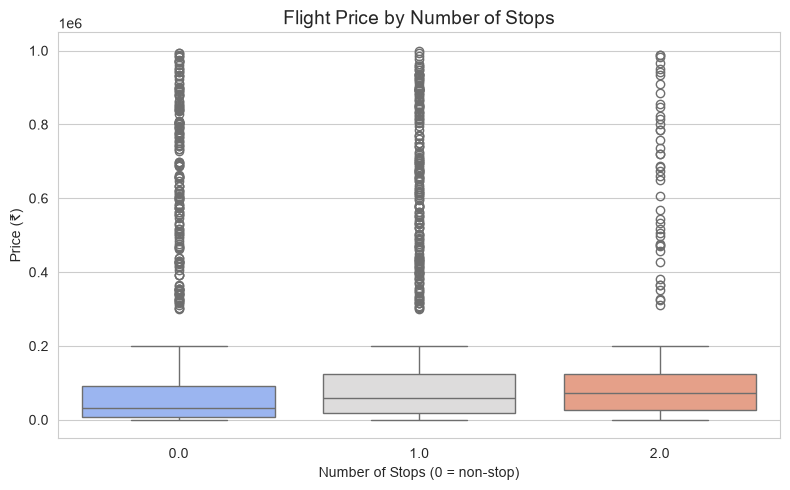

                median          mean  count
Total_Stops                                
0.0          32250.895  61609.096989  34574
1.0          60327.620  79510.286335  40073
2.0          71215.500  84681.120740  11184


In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Total_Stops', y='Price', palette='coolwarm')
plt.title('Flight Price by Number of Stops', fontsize=14)
plt.xlabel('Number of Stops (0 = non-stop)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

print(df.groupby('Total_Stops')['Price'].agg(['median', 'mean', 'count']))

**Insight:**
- Price rises with number of stops rather than falling — the opposite of the common
  assumption that connections are always cheaper.
- The likely explanation: in this dataset, longer/international routes are more likely
  to require a layover, so `Total_Stops` is probably acting as a proxy for route
  distance 